# **Lab 6 Hyperparameter Tuning**

In [3]:
%pip install torch torchvision matplotlib tqdm scikit-image opencv-python scikit-learn "ray[default]" "ray[tune]"

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.2/31.2 MB 31.2 MB/s  0:00:011.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pyarrow]━━━ 1/2 [pyarrow]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, SubsetRandomSampler, Dataset
import copy

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import os
import cv2
from skimage.util import random_noise
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from sklearn.model_selection import KFold
from ray.tune.schedulers import ASHAScheduler


seed = 4912
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

## Data Preparation
Complete the class `CustomImageDataset()` that `__getitem__` return ***noisy blury*** image and ***ground truth*** image.
Please ensure that the final image is in RGBscale and has a size of 128x128.

In [5]:
### START CODE HERE ###
class CustomImageDataset(Dataset):
    def __init__(
        self, image_paths, gauss_noise=False, gauss_blur=None, resize=128, p=0.5
    ):
        self.p = p
        self.resize = resize
        self.gauss_noise = gauss_noise
        self.gauss_blur = gauss_blur
        self.image_paths = image_paths

        if isinstance(image_paths, str) and os.path.isdir(image_paths):
            # It's a directory path - collect all image files
            self.image_paths = []
            for file_name in os.listdir(image_paths):
                if file_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.image_paths.append(os.path.join(image_paths, file_name))
            print(f"Found {len(self.image_paths)} images in {image_paths}")
        else:
            # It's already a list of image paths
            self.image_paths = image_paths
            print(f"Using provided list of {len(self.image_paths)} image paths")

    def __len__(self):
        return len(self.image_paths)

    def add_gaussian_noise(self, image, noise_factor=0.2, noise_scale=1.0):
        """
        Add Gaussian noise to an image tensor.
        image: torch.Tensor (C, H, W) in range [0,1]
        noise_factor: scaling factor for noise strength
        noise_scale: standard deviation of Gaussian noise
        """
        # Generate Gaussian noise
        noise = torch.randn_like(image) * noise_scale  # std = noise_scale
        
        # Apply noise factor
        noisy_image = image + noise_factor * noise
        
        # Clip to [0,1]
        noisy_image = torch.clamp(noisy_image, 0.0, 1.0)
        
        # Optionally add salt & pepper noise
        noisy_image = self.add_salt_pepper_noise(noisy_image, salt_prob=0.01, pepper_prob=0.01)
        
        return noisy_image


    def add_salt_pepper_noise(self, image, salt_prob=0.5, pepper_prob=0.5):
        noisy_image = image.clone()

        # Generate random mask for salt noise (white pixels)
        salt_mask = (
            torch.rand_like(image[0]) < salt_prob
        )  # Use only one channel for mask
        noisy_image[:, salt_mask] = 1.0  # Set all RGB channels to white

        # Generate random mask for pepper noise (black pixels)
        pepper_mask = (
            torch.rand_like(image[0]) < pepper_prob
        )  # Use only one channel for mask
        noisy_image[:, pepper_mask] = 0.0  # Set all RGB channels to black

        return noisy_image

    def add_gaussian_blur(self, image, kernel_size):
        blur_transform = transforms.GaussianBlur(
            kernel_size=kernel_size, sigma=(0.1, 2.0)
        )
        return blur_transform(image)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]

        # Load image using OpenCV
        gt_image = cv2.imread(image_path)

        # Check if image loaded successfully
        if gt_image is None:
            raise FileNotFoundError(f"Could not load image from: {image_path}")

        # Convert BGR to RGB
        gt_image = cv2.cvtColor(gt_image, cv2.COLOR_BGR2RGB)

        # Resize to target size
        gt_image = cv2.resize(gt_image, (self.resize, self.resize))

        # Convert to tensor and normalize to [0, 1] - this will be our clean ground truth
        gt_image_tensor = torch.from_numpy(gt_image).permute(2, 0, 1).float() / 255.0

        # Create noisy version by copying the ground truth
        noisy_image = gt_image_tensor.clone()

        # Apply Gaussian blur with probability p
        if self.gauss_blur is True:
            if random.random() < self.p:
                noisy_image = self.add_gaussian_blur(
                    noisy_image, kernel_size=random.choice([3, 5, 7, 9, 11])
                )

        # Apply Gaussian noise with probability p
        if self.gauss_noise is True:
            if random.random() < self.p:
                noisy_image = self.add_gaussian_noise(noisy_image, noise_factor=0.2, noise_scale=1.0)


        return noisy_image, gt_image_tensor
### END CODE HERE ###

In [6]:
### START CODE HERE ###
def imshow_grid(images):
    images = images[:16] 
    fig, axs = plt.subplots(4, 4, figsize=(6, 6))
    axs = axs.flatten()
    for img, ax in zip(images, axs):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.axis('off')
    plt.tight_layout()
    plt.show()
### END CODE HERE ###

In [7]:
# ### START CODE HERE ###
data_dir = "./img_align_celeba"
dataset = CustomImageDataset(data_dir, gauss_noise=True, gauss_blur=True, resize=128, p=0.5)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)  # Set proper batch_size, not None

print(f"Dataset created with {len(dataset)} images")
# ### END CODE HERE ###

Found 18000 images in ./img_align_celeba
Dataset created with 18000 images


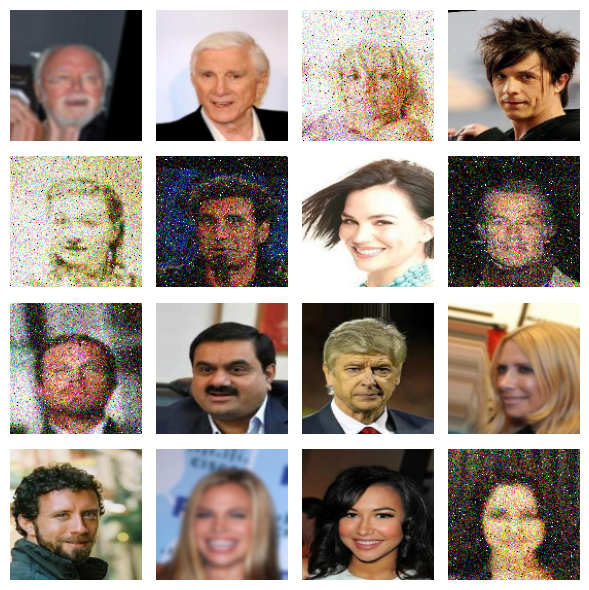

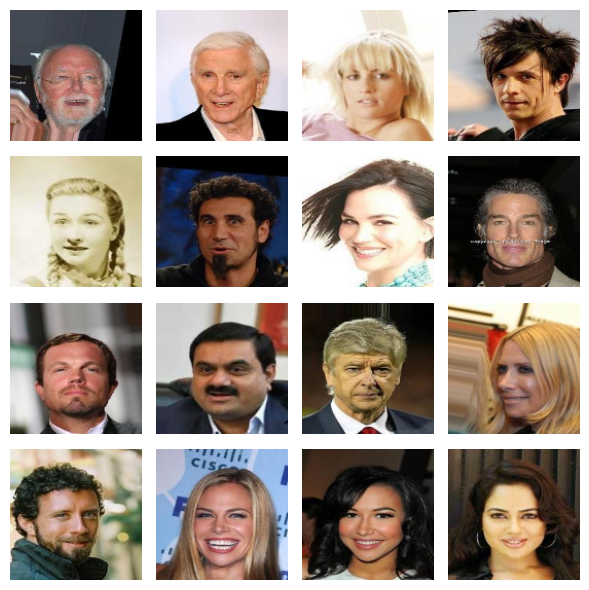

In [8]:
### START CODE HERE ###
batch,gt_img = next(iter(dataloader)) 
imshow_grid(batch)
imshow_grid(gt_img)



### END CODE HERE ###

## Create Autoencoder model
You can design your own Autoencoder model with a customizable number of downsampling and upsampling blocks by passing a list of channel numbers for each layer based on the provided code below. However, please maintain the concept of 'Autoencoder'.

In [9]:
### START CODE HERE ###
class DownSamplingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(DownSamplingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

class UpSamplingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(UpSamplingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.relu = nn.ReLU()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.upsample(x)
        return x

class Autoencoder(nn.Module):
    def __init__(self, channels=[64, 128, 256], input_channels=3, output_channels=3):
        super().__init__()
        
        # ---- Encoder ----
        self.encoders = nn.ModuleList()
        in_ch = input_channels
        for ch in channels:
            self.encoders.append(DownSamplingBlock(in_ch, ch))
            in_ch = ch

        # ---- Bottleneck ----
        self.bottleneck = nn.Sequential(
            nn.Conv2d(channels[-1], channels[-1], kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(channels[-1]),
            nn.ReLU(inplace=True)
        )

        # ---- Decoder ----
        self.decoders = nn.ModuleList()
        reversed_channels = list(reversed(channels))
        for i in range(len(reversed_channels) - 1):
            self.decoders.append(UpSamplingBlock(reversed_channels[i], reversed_channels[i+1]))
        
        # Final upsampling to restore to output_channels
        self.final = nn.Sequential(
            UpSamplingBlock(reversed_channels[-1], output_channels),
            nn.Conv2d(output_channels, output_channels, kernel_size=1)
        )

    def forward(self, x):
        # Encoder
        for encoder in self.encoders:
            x = encoder(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        for decoder in self.decoders:
            x = decoder(x)

        # Final
        x = self.final(x)

        return x
### END CODE HERE ###
        

## Train Autoencoder
Complete the `train()` function in the cell below. This function should evaluate the model at every epoch, log the ***training loss, test loss,test PSNR, test SSIM***. Additionally, it should save the model at the last epoch.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The log should resemble this, but not be identical

```
🤖Training on cuda
🚀Training Epoch [1/1]: 100%|██████████| 1313/1313 [01:45<00:00, 12.41batch/s, loss=0.0102] 
📄Testing: 100%|██████████| 563/563 [01:10<00:00,  7.95batch/s, loss=0.0106, psnr=16.7, ssim=0.348] 
Summary :
	Train	avg_loss: 0.017262999383663165
	Test	avg_loss: 0.010476540363861867 
                PSNR : 16.839487147468034 
                SSIM : 0.36090552368883694
...
```

</details>

Resource : [PyTorch Training loop](<https://pytorch.org/tutorials/beginner/introyt/trainingyt.html#:~:text=%3D0.9)-,The%20Training%20Loop,-Below%2C%20we%20have>), [PSNR & SSIM](https://ieeexplore.ieee.org/document/5596999)

In [10]:
import os

In [11]:
### START CODE HERE ###
def train(model, opt, loss_fn, train_loader, test_loader, epochs=10, checkpoint_path=None, device='cpu'):
    print("🤖Training on", device)
    model = model.to(device)
    
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        train_bar = tqdm(train_loader, desc=f'🚀Training Epoch [{epoch+1}/{epochs}]', unit='batch')
        
        for images, gt in train_bar:
            # Move data to device
            images = images.to(device)
            gt = gt.to(device)
            
            # Zero gradients
            opt.zero_grad()
            
            # Forward pass
            reconstructed = model(images)
            
            # Calculate loss
            loss = loss_fn(reconstructed, gt)
            
            # Backward pass
            loss.backward()
            
            # Update weights
            opt.step()
            
            # Accumulate loss
            epoch_train_loss += loss.item()
            
            # Update progress bar
            train_bar.set_postfix({'Loss': f'{loss.item():.4f}'})
        
        # Calculate average training loss
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Testing phase
        model.eval()
        psnr_scores = []
        ssim_scores = []
        epoch_test_loss = 0.0
        test_bar = tqdm(test_loader, desc='📄Testing', unit='batch')
        
        with torch.no_grad():
            for images, gt in test_bar:
                # Move data to device
                images = images.to(device)
                gt = gt.to(device)
                
                # Forward pass
                reconstructed = model(images)
                
                # Calculate loss
                loss = loss_fn(reconstructed, gt)
                
                # Accumulate loss
                epoch_test_loss += loss.item()

                imgs = images.cpu().numpy().transpose(0,2,3,1)
                recs = reconstructed.cpu().numpy().transpose(0,2,3,1)

                for i in range(imgs.shape[0]):
                    psnr_scores.append(psnr(imgs[i], recs[i], data_range=1.0))
                    ssim_scores.append(ssim(imgs[i], recs[i], channel_axis=-1, data_range=1.0))
                
                # Update progress bar
                test_bar.set_postfix({'Loss': f'{loss.item():.4f}',
                                       'PSNR': f'{float(np.mean(psnr_scores)):.4f}',
                                       'SSIM': f'{float(np.mean(ssim_scores)):.4f}'
                                    })
        # Calculate average test loss
        avg_test_loss = epoch_test_loss / len(test_loader)
        avg_psnr = float(np.mean(psnr_scores))
        avg_ssim = float(np.mean(ssim_scores))
        test_losses.append(avg_test_loss)
        
        # Print epoch summary
        print(f'Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, PSNR : {avg_psnr:.4f}, SSIM: {avg_ssim:.4f}')
        
        # Save checkpoint if path provided
        if checkpoint_path and (epoch + 1) % 5 == 0:  # Save every 5 epochs
            checkpoint_dir = os.path.dirname(checkpoint_path)
            os.makedirs(checkpoint_dir, exist_ok=True)

            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': opt.state_dict(),
                'train_loss': avg_train_loss,
                'test_loss': avg_test_loss,
                'psnr': avg_psnr,
                'ssim': avg_ssim,
            }, f'{checkpoint_path}_epoch_{epoch+1}.pth')
            print(f'Checkpoint saved at epoch {epoch+1}')
    
    return train_losses, test_losses
### END CODE HERE ###

In [12]:
def k_fold_cross_validation(model_class, dataset, optimizer_class, optimizer_params,
                                      num_folds=3, num_epochs=4, batch_size=16, device='cuda'):
    kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(np.arange(len(dataset)))):
        print(f"\n===== Fold {fold+1}/{num_folds} =====")

        # Subset samplers
        train_sampler = SubsetRandomSampler(train_idx)
        valid_sampler = SubsetRandomSampler(val_idx)
        train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler, num_workers=0)
        valid_loader = DataLoader(dataset, batch_size=batch_size, sampler=valid_sampler, num_workers=0)

        # Model, optimizer, loss
        model = model_class().to(device)
        optimizer = optimizer_class(model.parameters(), **optimizer_params)
        loss_fn = nn.MSELoss()

        for epoch in range(num_epochs):
            # ===== Training =====
            model.train()
            train_loss = 0.0

            for images, targets in train_loader:
                images, targets = images.to(device), targets.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = loss_fn(outputs, targets)
                loss.backward()
                optimizer.step()

                train_loss += loss.item() * images.size(0)

            avg_train_loss = train_loss / len(train_loader.dataset)

            # ===== Validation =====
            model.eval()
            val_loss = 0.0
            psnr_scores = []
            ssim_scores = []

            with torch.no_grad():
                for images, targets in valid_loader:
                    images, targets = images.to(device), targets.to(device)
                    outputs = model(images)
                    loss = loss_fn(outputs, targets)
                    val_loss += loss.item() * images.size(0)

                    # Convert to CPU numpy for metrics
                    imgs = images.cpu().numpy().transpose(0,2,3,1)
                    recs = outputs.cpu().numpy().transpose(0,2,3,1)
                    for i in range(imgs.shape[0]):
                        psnr_scores.append(psnr(imgs[i], recs[i], data_range=1.0))
                        ssim_scores.append(ssim(imgs[i], recs[i], channel_axis=-1, data_range=1.0))

            avg_val_loss = val_loss / len(valid_loader.dataset)
            avg_psnr = np.mean(psnr_scores)
            avg_ssim = np.mean(ssim_scores)

            print(f"Fold {fold+1}, Epoch [{epoch+1}/{num_epochs}]: "
                  f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, "
                  f"PSNR: {avg_psnr:.4f}, SSIM: {avg_ssim:.4f}")

        fold_results.append((avg_train_loss, avg_val_loss, avg_psnr, avg_ssim))

    # ===== Average results over all folds =====
    avg_train_loss = np.mean([r[0] for r in fold_results])
    avg_val_loss = np.mean([r[1] for r in fold_results])
    avg_psnr = np.mean([r[2] for r in fold_results])
    avg_ssim = np.mean([r[3] for r in fold_results])

    print("\n===== K-Fold Cross Validation Results =====")
    print(f"Average Train Loss: {avg_train_loss:.4f}, Average Val Loss: {avg_val_loss:.4f}")
    print(f"Average PSNR: {avg_psnr:.4f}, Average SSIM: {avg_ssim:.4f}")

    return fold_results, avg_train_loss, avg_val_loss, avg_psnr, avg_ssim

Let's train your model with 2 epochs to verify that your train() function works properly. After that, we'll move on to the Hyperparameter Grid Search in the next part.

In [13]:
### START CODE HERE ###

data_dir = "./img_align_celeba"

files = os.listdir(data_dir)
files = [os.path.join(data_dir, file) for file in files if file.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Split the dataset into training and testing sets
train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)

print(f"Total files: {len(files)}")
print(f"Train files: {len(train_files)}")
print(f"Test files: {len(test_files)}")

train_dataset = CustomImageDataset(train_files, gauss_noise=True, gauss_blur=True, resize=128, p=0.5)
test_dataset = CustomImageDataset(test_files, gauss_noise=True, gauss_blur=True, resize=128, p=0.5)
totat_dataset = CustomImageDataset(files, gauss_noise=True, gauss_blur=True, resize=128, p=0.5)


trainloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
testloader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)
### END CODE HERE ###

Total files: 18000
Train files: 14400
Test files: 3600
Using provided list of 14400 image paths
Using provided list of 3600 image paths
Using provided list of 18000 image paths


In [ ]:
### START CODE HERE ###

model = Autoencoder()
opt = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
train(model, opt, loss_fn, trainloader, testloader, epochs=2, checkpoint_path='/home/klamban/lab6/autoencoder_checkpoint', device='cuda' if torch.cuda.is_available() else 'cpu')

🤖Training on cuda


🚀Training Epoch [1/2]:   0%|          | 0/1500 [00:00<?, ?batch/s]

🚀Training Epoch [1/2]:  86%|████████▋ | 1296/1500 [09:26<01:29,  2.29batch/s, Loss=0.0193]


KeyboardInterrupt: 

---

## **Hyperparameter Grid Search with Raytune**

*If you have access to APEX, I would recommend converting this part into a Python file and submitting the job to run on APEX using SBATCH. This process may take a considerable amount of time.*

You can import additional Ray Tune tools as you want, such as schedulers, search algorithms, etc. Further information on the usage of Ray Tune can be found [here](https://docs.ray.io/en/latest/tune/index.html).

In [ ]:
%pip install "ray[tune]"

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import ray
from ray import tune
from ray.air import session


ray.shutdown()

Complete the `train_raytune()` function below, following the [quick start guide](https://docs.ray.io/en/latest/tune/index.html). This function will be passed to the `tune.Tuner`.

In [14]:
### START CODE HERE ###

def train_raytune(config):
    k_folds = 2
    device = "cuda" if torch.cuda.is_available() else "cpu"
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)

    fold_train_losses, fold_val_losses, fold_psnrs, fold_ssims = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(total_dataset)):
        print(f"\n[Fold {fold+1}/{k_folds}]")

        train_sampler = SubsetRandomSampler(train_idx)
        val_sampler = SubsetRandomSampler(val_idx)

        trainloader = DataLoader(
            total_dataset, batch_size=config["batch_size"], sampler=train_sampler, num_workers=0
        )

        valloader = DataLoader(
            total_dataset, batch_size=config["batch_size"], sampler=val_sampler, num_workers=0
        )

        # Initialize model and optimizer fresh for each fold
        model = Autoencoder(config["architecture"]).to(device)
        loss_fn = nn.MSELoss()

        if config["optimizer"] == "Adam":
            opt = torch.optim.Adam(model.parameters(), lr=config["lr"])
        elif config["optimizer"] == "RMSProp":
            opt = torch.optim.RMSprop(model.parameters(), lr=config["lr"])

        for epoch in range(config["num_epochs"]):
            # -------------------- Train --------------------
            model.train()
            epoch_train_loss = 0.0
            for images, gt in trainloader:
                images, gt = images.to(device), gt.to(device)

                outputs = model(images)
                loss = loss_fn(outputs, gt)

                opt.zero_grad()
                loss.backward()
                opt.step()

                epoch_train_loss += loss.item()
            avg_train_loss = epoch_train_loss / len(trainloader)

            # -------------------- Eval --------------------
            model.eval()
            epoch_val_loss = 0.0
            psnr_scores, ssim_scores = [], []

            with torch.no_grad():
                for images, gt in valloader:
                    images, gt = images.to(device), gt.to(device)
                    reconstructed = model(images)
                    loss = loss_fn(reconstructed, gt)
                    epoch_val_loss += loss.item()

                    imgs = gt.cpu().numpy().transpose(0, 2, 3, 1)
                    recs = reconstructed.cpu().numpy().transpose(0, 2, 3, 1)

                    for i in range(imgs.shape[0]):
                        psnr_scores.append(psnr(imgs[i], recs[i], data_range=1.0))
                        ssim_scores.append(
                            ssim(imgs[i], recs[i], channel_axis=-1, data_range=1.0)
                        )

            avg_val_loss = epoch_val_loss / len(valloader)
            avg_psnr = np.mean(psnr_scores)
            avg_ssim = np.mean(ssim_scores)

            # Save results for this fold
            fold_train_losses.append(avg_train_loss)
            fold_val_losses.append(avg_val_loss)
            fold_psnrs.append(avg_psnr)
            fold_ssims.append(avg_ssim)

    # -------------------- Report average of 2 folds --------------------
    session.report(
        {
            "train_loss": np.mean(fold_train_losses),
            "val_loss": np.mean(fold_val_losses),
            "val_psnr": np.mean(fold_psnrs),
            "val_ssim": np.mean(fold_ssims),
        }
    )

### END CODE HERE ###

Initialize Ray, define the search space, and resources.

Resource : 
- [A Guide To Parallelism and Resources for Ray Tune](https://docs.ray.io/en/latest/tune/tutorials/tune-resources.html#:~:text=A%20Guide%20To%20Parallelism%20and%20Resources%20for%20Ray%20Tune) 
- [Working with Tune Search Spaces](https://docs.ray.io/en/latest/tune/tutorials/tune-search-spaces.html#tune-search-space-tutorial:~:text=Working%20with%20Tune%20Search%20Spaces)
- [How to configure logging in Tune?](https://docs.ray.io/en/latest/tune/tutorials/tune-output.html) 
- [Tune Trial Schedulers (`tune.schedulers`)](https://docs.ray.io/en/latest/tune/api/schedulers.html#tune-scheduler-pbt:~:text=Tune%20Trial...-,Tune%20Trial%20Schedulers%20(tune.schedulers),-%23)

**Search Space:**
- `architecture`:<br>
    Feature map dimensions for convolutional layers<br>
    - `[32, 64, 128]`: 3 downsampling layers with feature maps increasing from 32 to 128.
    - `[64, 128, 256]`: 3 downsampling layers with feature maps starting from 64 to 256.
    - `[64, 128, 256, 512]`: 4 downsampling layers with more depth, starting from 64 and ending at 512.
- `learning rates (lr)`:
    - [1e-3, 8e-4, 1e-4, 1e-2]: Test a wide range of learning rates to evaluate model performance, from 1e-3 (typical) to a more aggressive 1e-2 or conservative 1e-4.
- `batch size`:
    - [16, 32]: Explore smaller batch sizes to evaluate their impact on gradient estimation and memory usage.
- `number of epochs`:
    - `[10, 50, 100]`: Allow short and long training sessions, from quick evaluations (10 epochs) to more extensive training (100 epochs).
- `optimizers (opts)`:
    - `["Adam", "SGD"]`: Compare two popular optimization algorithms: Adam for adaptive learning rates and SGD for momentum-based updates.

In [ ]:
from ray import tune

config = {
    "architecture": tune.grid_search(
        [[32, 64, 128], [64, 128, 256], [64, 128, 256, 512]]
    ),
    "lr": tune.grid_search([0.01, 0.0001]),
    # "lr": tune.grid_search([0.001, 0.0008, 0.0001, 0.01]),
    "batch_size": tune.grid_search([2, 16]),
    "num_epochs": tune.grid_search([100, 300]),
    "optimizer": tune.grid_search(["Adam", "RMSProp"]),
}

tuner = tune.Tuner(
    tune.with_resources(train_raytune, resources={"gpu": 1}),
    tune_config=tune.TuneConfig(
        metric="val_psnr",
        mode="max",
        scheduler=ASHAScheduler(),
    ),
    param_space=config,
    run_config=tune.RunConfig(
        storage_path="/home/klamban/ray_results_grid_plus_rV2", name="train_raytune"
    ),
)

result = tuner.fit()


2025-08-31 11:25:14,943	WARNING tune_controller.py:2132 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (281 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2025-08-31 11:25:14,947	WARNING tune_controller.py:2132 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (281 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.


Restore the result from path of ray resule directory

In [ ]:
# ### START CODE HERE ###
exp_path = os.path.join("/home/klamban/ray_results_grid_plus_rV2", "train_raytune")
restored_tuner = tune.Tuner.restore(
    exp_path,
    trainable=tune.with_resources(train_raytune, resources={"gpu": 1}),
    resume_unfinished=True,
    resume_errored=True,
)
# ### END CODE HERE ###

FileNotFoundError: [Errno 2] Failed to open local file '/home/klamban/ray_results/tuner.pkl'. Detail: [errno 2] No such file or directory

Get the report from Grid Search to CSV file.

In [ ]:
print("🎉[INFO] Training is done!")
print("Best config is:", result.get_best_result().config)
print("Best result is:", result.get_best_result())

save_dir = "/home/klamban/lab6"
os.makedirs(save_dir, exist_ok=True)

df = result.get_dataframe()
csv_path = os.path.join(save_dir, "raytune_results_grid_v2.csv")
df.to_csv(csv_path, index=False)


---

Train the Autoencoder models using the best hyperparameter set obtained from the grid search.

In [15]:
class FeatureExtractor(nn.Module):
    def __init__(self, model, target_layers):
        super(FeatureExtractor, self).__init__()
        self.model = copy.deepcopy(model)
        self.target_layers = target_layers
        self.features = []

        for layer_name, layer in self.model.named_modules():
            if layer_name in target_layers:
                layer.register_forward_hook(self.save_feature(layer_name))

    def save_feature(self, layer_name):
        def hook(module, input, output):
            self.features.append(output)
        return hook

    def forward(self, x):
        self.features = []
        self.model(x)
        return self.features

In [17]:
### START CODE HERE ###
def visualize_feature_map(x, base_filename):
    # Get ALL layers that produce meaningful feature maps
    target_layers = []
    layer_info = []
    
    print("Scanning model architecture...")
    for name, module in model.named_modules():
        # Include Conv2d, ConvTranspose2d, Linear, and activation layers
        if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear, nn.ReLU, nn.Sigmoid, nn.Tanh)) and name != '':
            target_layers.append(name)
            layer_info.append((name, module.__class__.__name__))
            print(f"  {name}: {module.__class__.__name__}")
    
    print(f"\nTotal layers to visualize: {len(target_layers)}")
    print("="*60)
    
    # Create feature extractor
    feature_extractor = FeatureExtractor(model, target_layers)
    
    # Extract features from ALL layers
    with torch.no_grad():
        features = feature_extractor(x)
    
    print(f"Successfully extracted features from {len(features)} layers\n")
    
    # Prepare data for visualization
    all_feature_data = []
    total_subplots = 0
    
    for i, (feature, (layer_name, layer_type)) in enumerate(zip(features, layer_info)):
        print(f"Processing {layer_name} ({layer_type}): {feature.shape}")
        
        if len(feature.shape) == 4:  # Conv/ConvTranspose layers: [batch, channels, H, W]
            feature_map = feature[0]  # Take first batch
            # Show more channels for comprehensive visualization
            num_channels = min(16, feature_map.shape[0])  # Show up to 16 channels per layer
            
            for ch in range(num_channels):
                all_feature_data.append({
                    'data': feature_map[ch].cpu().numpy(),
                    'title': f'{layer_name}\nCh{ch}',
                    'type': '2d',
                    'layer_type': layer_type
                })
                total_subplots += 1
                
        elif len(feature.shape) == 2:  # Linear layers: [batch, features]
            feature_vec = feature[0].cpu().numpy()  # Take first batch
            all_feature_data.append({
                'data': feature_vec,
                'title': f'{layer_name}\n({len(feature_vec)} units)',
                'type': '1d',
                'layer_type': layer_type
            })
            total_subplots += 1
    
    print(f"\nTotal feature maps to display: {total_subplots}")
    
    # Create comprehensive grid layout with 12 columns
    cols = 12  # 12 columns as requested
    rows = (total_subplots + cols - 1) // cols
    
    # Create the mega-plot
    fig, axes = plt.subplots(rows, cols, figsize=(30, rows * 2.5))  # Wider figure for 12 columns
    fig.suptitle(f'Complete Feature Map Visualization - All Layers', fontsize=28, y=0.98)
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    # Plot all feature maps
    for idx, feature_data in enumerate(all_feature_data):
        if idx < len(axes):
            ax = axes[idx]
            data = feature_data['data']
            title = feature_data['title']
            plot_type = feature_data['type']
            
            if plot_type == '2d':
                # 2D feature maps (convolutional layers)
                im = ax.imshow(data, cmap='viridis', aspect='auto')
                ax.set_title(title, fontsize=7, pad=2)
                ax.axis('off')
                
            elif plot_type == '1d':
                # 1D feature vectors (linear layers)
                if len(data) <= 200:
                    ax.bar(range(len(data)), data, width=0.8, alpha=0.7)
                else:
                    # For large vectors, show sample
                    sample_indices = np.linspace(0, len(data)-1, 200, dtype=int)
                    ax.plot(sample_indices, data[sample_indices], linewidth=1, marker='o', markersize=1)
                
                ax.set_title(title, fontsize=7, pad=2)
                ax.tick_params(labelsize=5)
                ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(all_feature_data), len(axes)):
        axes[idx].axis('off')
    
    # Adjust layout for 12 columns
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.subplots_adjust(wspace=0.1, hspace=0.3)  # Adjust spacing for better visibility
    
    # Save with high DPI for clarity
    plt.savefig(f'{base_filename}_all_layers_12col.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print comprehensive summary
    print("\n" + "="*60)
    print("VISUALIZATION COMPLETE")
    print("="*60)
    print(f"Layers processed: {len(target_layers)}")
    print(f"Feature maps displayed: {len(all_feature_data)}")
    print(f"Grid size: {rows} x {cols}")
    print(f"Saved as: {base_filename}_all_layers_12col.png")

### END CODE HERE ###

Input shape: torch.Size([1, 3, 128, 128])
Scanning model architecture...
  encoders.0.conv: Conv2d
  encoders.0.relu: ReLU
  encoders.1.conv: Conv2d
  encoders.1.relu: ReLU
  encoders.2.conv: Conv2d
  encoders.2.relu: ReLU
  bottleneck.0: Conv2d
  bottleneck.2: ReLU
  decoders.0.conv: Conv2d
  decoders.0.relu: ReLU
  decoders.1.conv: Conv2d
  decoders.1.relu: ReLU
  final.0.conv: Conv2d
  final.0.relu: ReLU
  final.1: Conv2d

Total layers to visualize: 15
Successfully extracted features from 15 layers

Processing encoders.0.conv (Conv2d): torch.Size([1, 64, 128, 128])
Processing encoders.0.relu (ReLU): torch.Size([1, 64, 128, 128])
Processing encoders.1.conv (Conv2d): torch.Size([1, 128, 64, 64])
Processing encoders.1.relu (ReLU): torch.Size([1, 128, 64, 64])
Processing encoders.2.conv (Conv2d): torch.Size([1, 256, 32, 32])
Processing encoders.2.relu (ReLU): torch.Size([1, 256, 32, 32])
Processing bottleneck.0 (Conv2d): torch.Size([1, 256, 16, 16])
Processing bottleneck.2 (ReLU): torch

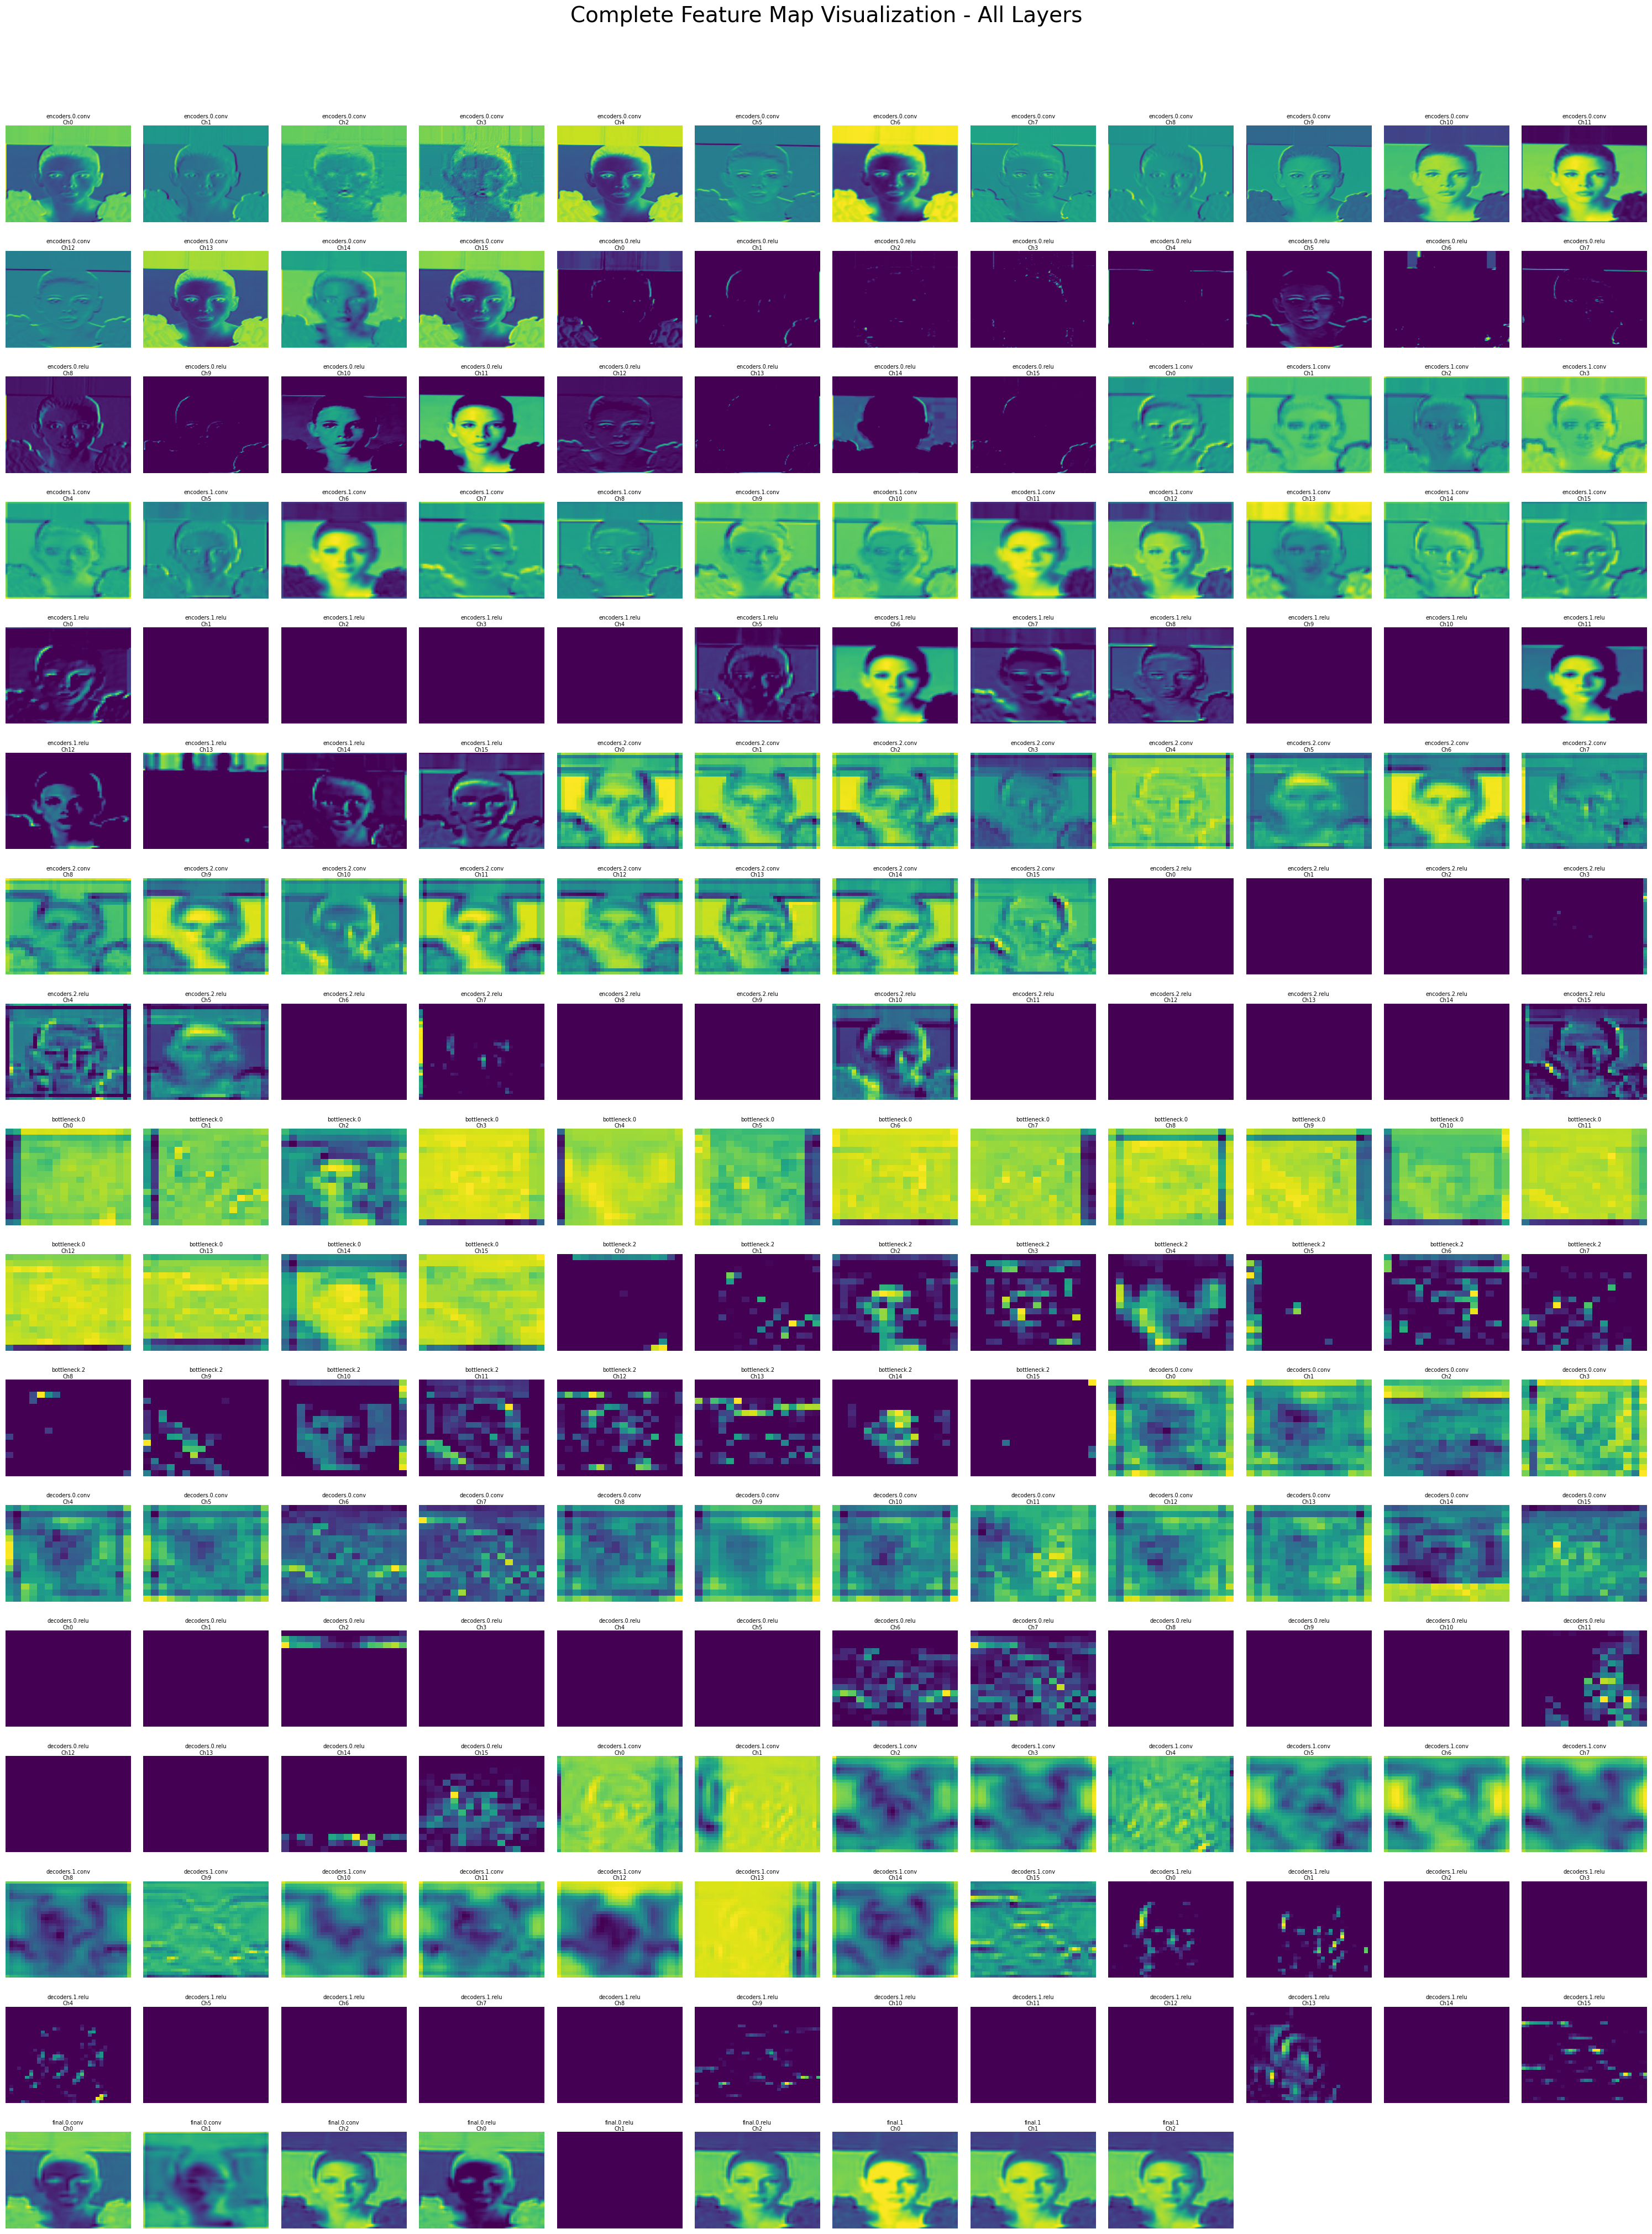


VISUALIZATION COMPLETE
Layers processed: 15
Feature maps displayed: 201
Grid size: 17 x 12
Saved as: autoencoder_features_all_layers_12col.png


In [23]:
model = Autoencoder(channels=[64, 128, 256])
checkpoint = torch.load(
    "./grid_autoencoder_checkpoint_epoch_100.pth",
    map_location="cpu"
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Pick one sample from your test loader
sample_input, _ = next(iter(testloader))
sample_input = sample_input[:1]  # only one image for visualization

print("Input shape:", sample_input.shape)
print("="*60)

# Visualize ALL feature maps in 12-column layout
visualize_feature_map(sample_input, "autoencoder_features")

Use the `FeatureExtractor()` class and `visualize_feature_map()` function to visualize the feature map of ***ALL*** layers. Then, save it as an image.


In [20]:
class FeatureExtractor(nn.Module):
    def __init__(self, model, target_layers):
        super(FeatureExtractor, self).__init__()
        self.model = copy.deepcopy(model)
        self.target_layers = target_layers
        self.features = []

        for layer_name, layer in self.model.named_modules():
            if layer_name in target_layers:
                layer.register_forward_hook(self.save_feature(layer_name))

    def save_feature(self, layer_name):
        def hook(module, input, output):
            self.features.append(output)
        return hook

    def forward(self, x):
        self.features = []
        self.model(x)
        return self.features


### START CODE HERE ###
def visualize_feature_map(x, base_filename):
    # Get ALL layers that produce meaningful feature maps
    target_layers = []
    layer_info = []
    
    print("Scanning model architecture...")
    for name, module in model.named_modules():
        # Include Conv2d, ConvTranspose2d, Linear, and activation layers
        if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear, nn.ReLU, nn.Sigmoid, nn.Tanh)) and name != '':
            target_layers.append(name)
            layer_info.append((name, module.__class__.__name__))
            print(f"  {name}: {module.__class__.__name__}")
    
    print(f"\nTotal layers to visualize: {len(target_layers)}")
    print("="*60)
    
    # Create feature extractor
    feature_extractor = FeatureExtractor(model, target_layers)
    
    # Extract features from ALL layers
    with torch.no_grad():
        features = feature_extractor(x)
    
    print(f"Successfully extracted features from {len(features)} layers\n")
    
    # Prepare data for visualization
    all_feature_data = []
    total_subplots = 0
    
    for i, (feature, (layer_name, layer_type)) in enumerate(zip(features, layer_info)):
        print(f"Processing {layer_name} ({layer_type}): {feature.shape}")
        
        if len(feature.shape) == 4:  # Conv/ConvTranspose layers: [batch, channels, H, W]
            feature_map = feature[0]  # Take first batch
            # Show more channels for comprehensive visualization
            num_channels = min(16, feature_map.shape[0])  # Show up to 16 channels per layer
            
            for ch in range(num_channels):
                all_feature_data.append({
                    'data': feature_map[ch].cpu().numpy(),
                    'title': f'{layer_name}\nCh{ch}',
                    'type': '2d',
                    'layer_type': layer_type
                })
                total_subplots += 1
                
        elif len(feature.shape) == 2:  # Linear layers: [batch, features]
            feature_vec = feature[0].cpu().numpy()  # Take first batch
            all_feature_data.append({
                'data': feature_vec,
                'title': f'{layer_name}\n({len(feature_vec)} units)',
                'type': '1d',
                'layer_type': layer_type
            })
            total_subplots += 1
    
    print(f"\nTotal feature maps to display: {total_subplots}")
    
    # Create comprehensive grid layout with 12 columns
    cols = 12  # 12 columns as requested
    rows = (total_subplots + cols - 1) // cols
    
    # Create the mega-plot
    fig, axes = plt.subplots(rows, cols, figsize=(30, rows * 2.5))  # Wider figure for 12 columns
    fig.suptitle(f'Complete Feature Map Visualization - All Layers', fontsize=28, y=0.98)
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    # Plot all feature maps
    for idx, feature_data in enumerate(all_feature_data):
        if idx < len(axes):
            ax = axes[idx]
            data = feature_data['data']
            title = feature_data['title']
            plot_type = feature_data['type']
            
            if plot_type == '2d':
                # 2D feature maps (convolutional layers)
                im = ax.imshow(data, cmap='viridis', aspect='auto')
                ax.set_title(title, fontsize=7, pad=2)
                ax.axis('off')
                
            elif plot_type == '1d':
                # 1D feature vectors (linear layers)
                if len(data) <= 200:
                    ax.bar(range(len(data)), data, width=0.8, alpha=0.7)
                else:
                    # For large vectors, show sample
                    sample_indices = np.linspace(0, len(data)-1, 200, dtype=int)
                    ax.plot(sample_indices, data[sample_indices], linewidth=1, marker='o', markersize=1)
                
                ax.set_title(title, fontsize=7, pad=2)
                ax.tick_params(labelsize=5)
                ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(all_feature_data), len(axes)):
        axes[idx].axis('off')
    
    # Adjust layout for 12 columns
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.subplots_adjust(wspace=0.1, hspace=0.3)  # Adjust spacing for better visibility
    
    # Save with high DPI for clarity
    plt.savefig(f'{base_filename}_all_layers_12col.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print comprehensive summary
    print("\n" + "="*60)
    print("VISUALIZATION COMPLETE")
    print("="*60)
    print(f"Layers processed: {len(target_layers)}")
    print(f"Feature maps displayed: {len(all_feature_data)}")
    print(f"Grid size: {rows} x {cols}")
    print(f"Saved as: {base_filename}_all_layers_12col.png")

### END CODE HERE ###

---
## **Hyperparameter Random Search with Raytune**

**Search Space:**

- **`architecture`:**  
    Define the feature map dimensions for convolutional layers:  
    - `[32, 64, 128]`: 3 downsampling layers with feature maps increasing from 32 to 128.
    - `[64, 128, 256]`: 3 downsampling layers with feature maps starting from 64 to 256.
    - `[64, 128, 256, 512]`: 4 downsampling layers with additional depth, starting from 64 and ending at 512.
  
- **`learning rates (lr)`**:  
    A continuous range of learning rates sampled uniformly between `1e-4` and `1e-2`. This allows exploration of different learning rates from conservative (`1e-4`) to more aggressive (`1e-2`) values.

- **`batch size`**:  
    Randomly sample an integer batch size between 16 and 32 (inclusive). This allows testing of smaller batch sizes, which can affect gradient estimation and memory usage.

- **`number of epochs`**:  
    Randomly sample an integer number of epochs between 10 and 100. This allows the model to train for short (e.g., 10 epochs) or extended periods (up to 100 epochs), giving insight into model performance over different training durations.

- **`optimizers (opts)`**:  
    Randomly select between two optimizers:  
    - `"Adam"`: An adaptive learning rate optimizer that generally performs well across various tasks.  
    - `"SGD"`: Stochastic Gradient Descent with momentum, commonly used for large-scale tasks, requiring careful tuning of the learning rate.

***NOTE*** Random search with 80 samples.

In [ ]:
from ray import tune
from ray.tune.schedulers import ASHAScheduler

ray.init(num_gpus=1)

config = {
    "architecture": tune.choice(
        [[32, 64, 128], [64, 128, 256], [64, 128, 256, 512]]
    ),
    "lr": tune.choice([0.01, 0.0001]),
    "batch_size": tune.choice([2, 16]),
    "num_epochs": tune.randint(100, 300),
    "optimizer": tune.choice(["Adam", "RMSProp"]),
}

tuner = tune.Tuner(
    tune.with_resources(train_raytune, resources={"gpu": 1}),
    tune_config=tune.TuneConfig(
        metric="val_psnr",
        mode="max",
        num_samples=80,
        scheduler=ASHAScheduler()
    ),
    param_space=config,
    run_config=tune.RunConfig(
        storage_path="/home/klamban/ray_results_random",
        name="train_raytune"
    )
)

result = tuner.fit()

In [ ]:
print("🎉[INFO] Training is done!")
print("Best config is:", result.get_best_result().config)
print("Best result is:", result.get_best_result())

save_dir = "/home/klamban/lab6"
os.makedirs(save_dir, exist_ok=True)

df = result.get_dataframe()
csv_path = os.path.join(save_dir, "raytune_results_random.csv")
df.to_csv(csv_path, index=False)


ray.shutdown()

---

Train the Autoencoder models using the best hyperparameter set obtained from the random search.

In [ ]:
### START CODE HERE ###

# best_config = {
#     "architecture": [64, 128, 256],
#     "lr": 0.0002785101723106558,
#     "batch_size": 16,
#     "num_epochs": 83,
#     "optimizer": "Adam",
# }

# model = Autoencoder(channels=best_config["architecture"])
# opt = optim.Adam(model.parameters(), lr=best_config["lr"])
# loss_fn = nn.MSELoss()
# trainloader = DataLoader(
#     train_dataset, batch_size=best_config["batch_size"], shuffle=True, num_workers=0
# )
# testloader = DataLoader(
#     test_dataset, batch_size=best_config["batch_size"], shuffle=False, num_workers=0
# )
# train(
#     model,
#     opt,
#     loss_fn,
#     trainloader,
#     testloader,
#     epochs=best_config["num_epochs"],
#     checkpoint_path="/home/klamban/lab6/random_autoencoder_checkpoint",
#     device="cuda" if torch.cuda.is_available() else "cpu",
# )
### END CODE HERE ###

Use the `FeatureExtractor()` class and `visualize_feature_map()` function to visualize the feature map of ***ALL*** layers of the Convolution Feature Extractor part. Then, save it as an image.

In [ ]:
### START CODE HERE ###

class FeatureExtractor(nn.Module):
    def __init__(self, model, target_layers):
        super(FeatureExtractor, self).__init__()
        self.model = copy.deepcopy(model)
        self.target_layers = target_layers
        self.features = []

        for layer_name, layer in self.model.named_modules():
            if layer_name in target_layers:
                layer.register_forward_hook(self.save_feature(layer_name))

    def save_feature(self, layer_name):
        def hook(module, input, output):
            self.features.append(output)
        return hook

    def forward(self, x):
        self.features = []
        self.model(x)
        return self.features


### START CODE HERE ###
def visualize_feature_map(x, base_filename):
    # Get ALL layers that produce meaningful feature maps
    target_layers = []
    layer_info = []
    
    print("Scanning model architecture...")
    for name, module in model.named_modules():
        # Include Conv2d, ConvTranspose2d, Linear, and activation layers
        if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear, nn.ReLU, nn.Sigmoid, nn.Tanh)) and name != '':
            target_layers.append(name)
            layer_info.append((name, module.__class__.__name__))
            print(f"  {name}: {module.__class__.__name__}")
    
    print(f"\nTotal layers to visualize: {len(target_layers)}")
    print("="*60)
    
    # Create feature extractor
    feature_extractor = FeatureExtractor(model, target_layers)
    
    # Extract features from ALL layers
    with torch.no_grad():
        features = feature_extractor(x)
    
    print(f"Successfully extracted features from {len(features)} layers\n")
    
    # Prepare data for visualization
    all_feature_data = []
    total_subplots = 0
    
    for i, (feature, (layer_name, layer_type)) in enumerate(zip(features, layer_info)):
        print(f"Processing {layer_name} ({layer_type}): {feature.shape}")
        
        if len(feature.shape) == 4:  # Conv/ConvTranspose layers: [batch, channels, H, W]
            feature_map = feature[0]  # Take first batch
            # Show more channels for comprehensive visualization
            num_channels = min(16, feature_map.shape[0])  # Show up to 16 channels per layer
            
            for ch in range(num_channels):
                all_feature_data.append({
                    'data': feature_map[ch].cpu().numpy(),
                    'title': f'{layer_name}\nCh{ch}',
                    'type': '2d',
                    'layer_type': layer_type
                })
                total_subplots += 1
                
        elif len(feature.shape) == 2:  # Linear layers: [batch, features]
            feature_vec = feature[0].cpu().numpy()  # Take first batch
            all_feature_data.append({
                'data': feature_vec,
                'title': f'{layer_name}\n({len(feature_vec)} units)',
                'type': '1d',
                'layer_type': layer_type
            })
            total_subplots += 1
    
    print(f"\nTotal feature maps to display: {total_subplots}")
    
    # Create comprehensive grid layout with 12 columns
    cols = 12  # 12 columns as requested
    rows = (total_subplots + cols - 1) // cols
    
    # Create the mega-plot
    fig, axes = plt.subplots(rows, cols, figsize=(30, rows * 2.5))  # Wider figure for 12 columns
    fig.suptitle(f'Complete Feature Map Visualization - All Layers', fontsize=28, y=0.98)
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    # Plot all feature maps
    for idx, feature_data in enumerate(all_feature_data):
        if idx < len(axes):
            ax = axes[idx]
            data = feature_data['data']
            title = feature_data['title']
            plot_type = feature_data['type']
            
            if plot_type == '2d':
                # 2D feature maps (convolutional layers)
                im = ax.imshow(data, cmap='viridis', aspect='auto')
                ax.set_title(title, fontsize=7, pad=2)
                ax.axis('off')
                
            elif plot_type == '1d':
                # 1D feature vectors (linear layers)
                if len(data) <= 200:
                    ax.bar(range(len(data)), data, width=0.8, alpha=0.7)
                else:
                    # For large vectors, show sample
                    sample_indices = np.linspace(0, len(data)-1, 200, dtype=int)
                    ax.plot(sample_indices, data[sample_indices], linewidth=1, marker='o', markersize=1)
                
                ax.set_title(title, fontsize=7, pad=2)
                ax.tick_params(labelsize=5)
                ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(all_feature_data), len(axes)):
        axes[idx].axis('off')
    
    # Adjust layout for 12 columns
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.subplots_adjust(wspace=0.1, hspace=0.3)  # Adjust spacing for better visibility
    
    # Save with high DPI for clarity
    plt.savefig(f'{base_filename}_all_layers_12col.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print comprehensive summary
    print("\n" + "="*60)
    print("VISUALIZATION COMPLETE")
    print("="*60)
    print(f"Layers processed: {len(target_layers)}")
    print(f"Feature maps displayed: {len(all_feature_data)}")
    print(f"Grid size: {rows} x {cols}")
    print(f"Saved as: {base_filename}_all_layers_12col.png")

### END CODE HERE ###

Input shape: torch.Size([1, 3, 128, 128])
Scanning model architecture...
  encoders.0.conv: Conv2d
  encoders.0.relu: ReLU
  encoders.1.conv: Conv2d
  encoders.1.relu: ReLU
  encoders.2.conv: Conv2d
  encoders.2.relu: ReLU
  bottleneck.0: Conv2d
  bottleneck.2: ReLU
  decoders.0.conv: Conv2d
  decoders.0.relu: ReLU
  decoders.1.conv: Conv2d
  decoders.1.relu: ReLU
  final.0.conv: Conv2d
  final.0.relu: ReLU
  final.1: Conv2d

Total layers to visualize: 15
Successfully extracted features from 15 layers

Processing encoders.0.conv (Conv2d): torch.Size([1, 64, 128, 128])
Processing encoders.0.relu (ReLU): torch.Size([1, 64, 128, 128])
Processing encoders.1.conv (Conv2d): torch.Size([1, 128, 64, 64])
Processing encoders.1.relu (ReLU): torch.Size([1, 128, 64, 64])
Processing encoders.2.conv (Conv2d): torch.Size([1, 256, 32, 32])
Processing encoders.2.relu (ReLU): torch.Size([1, 256, 32, 32])
Processing bottleneck.0 (Conv2d): torch.Size([1, 256, 16, 16])
Processing bottleneck.2 (ReLU): torch

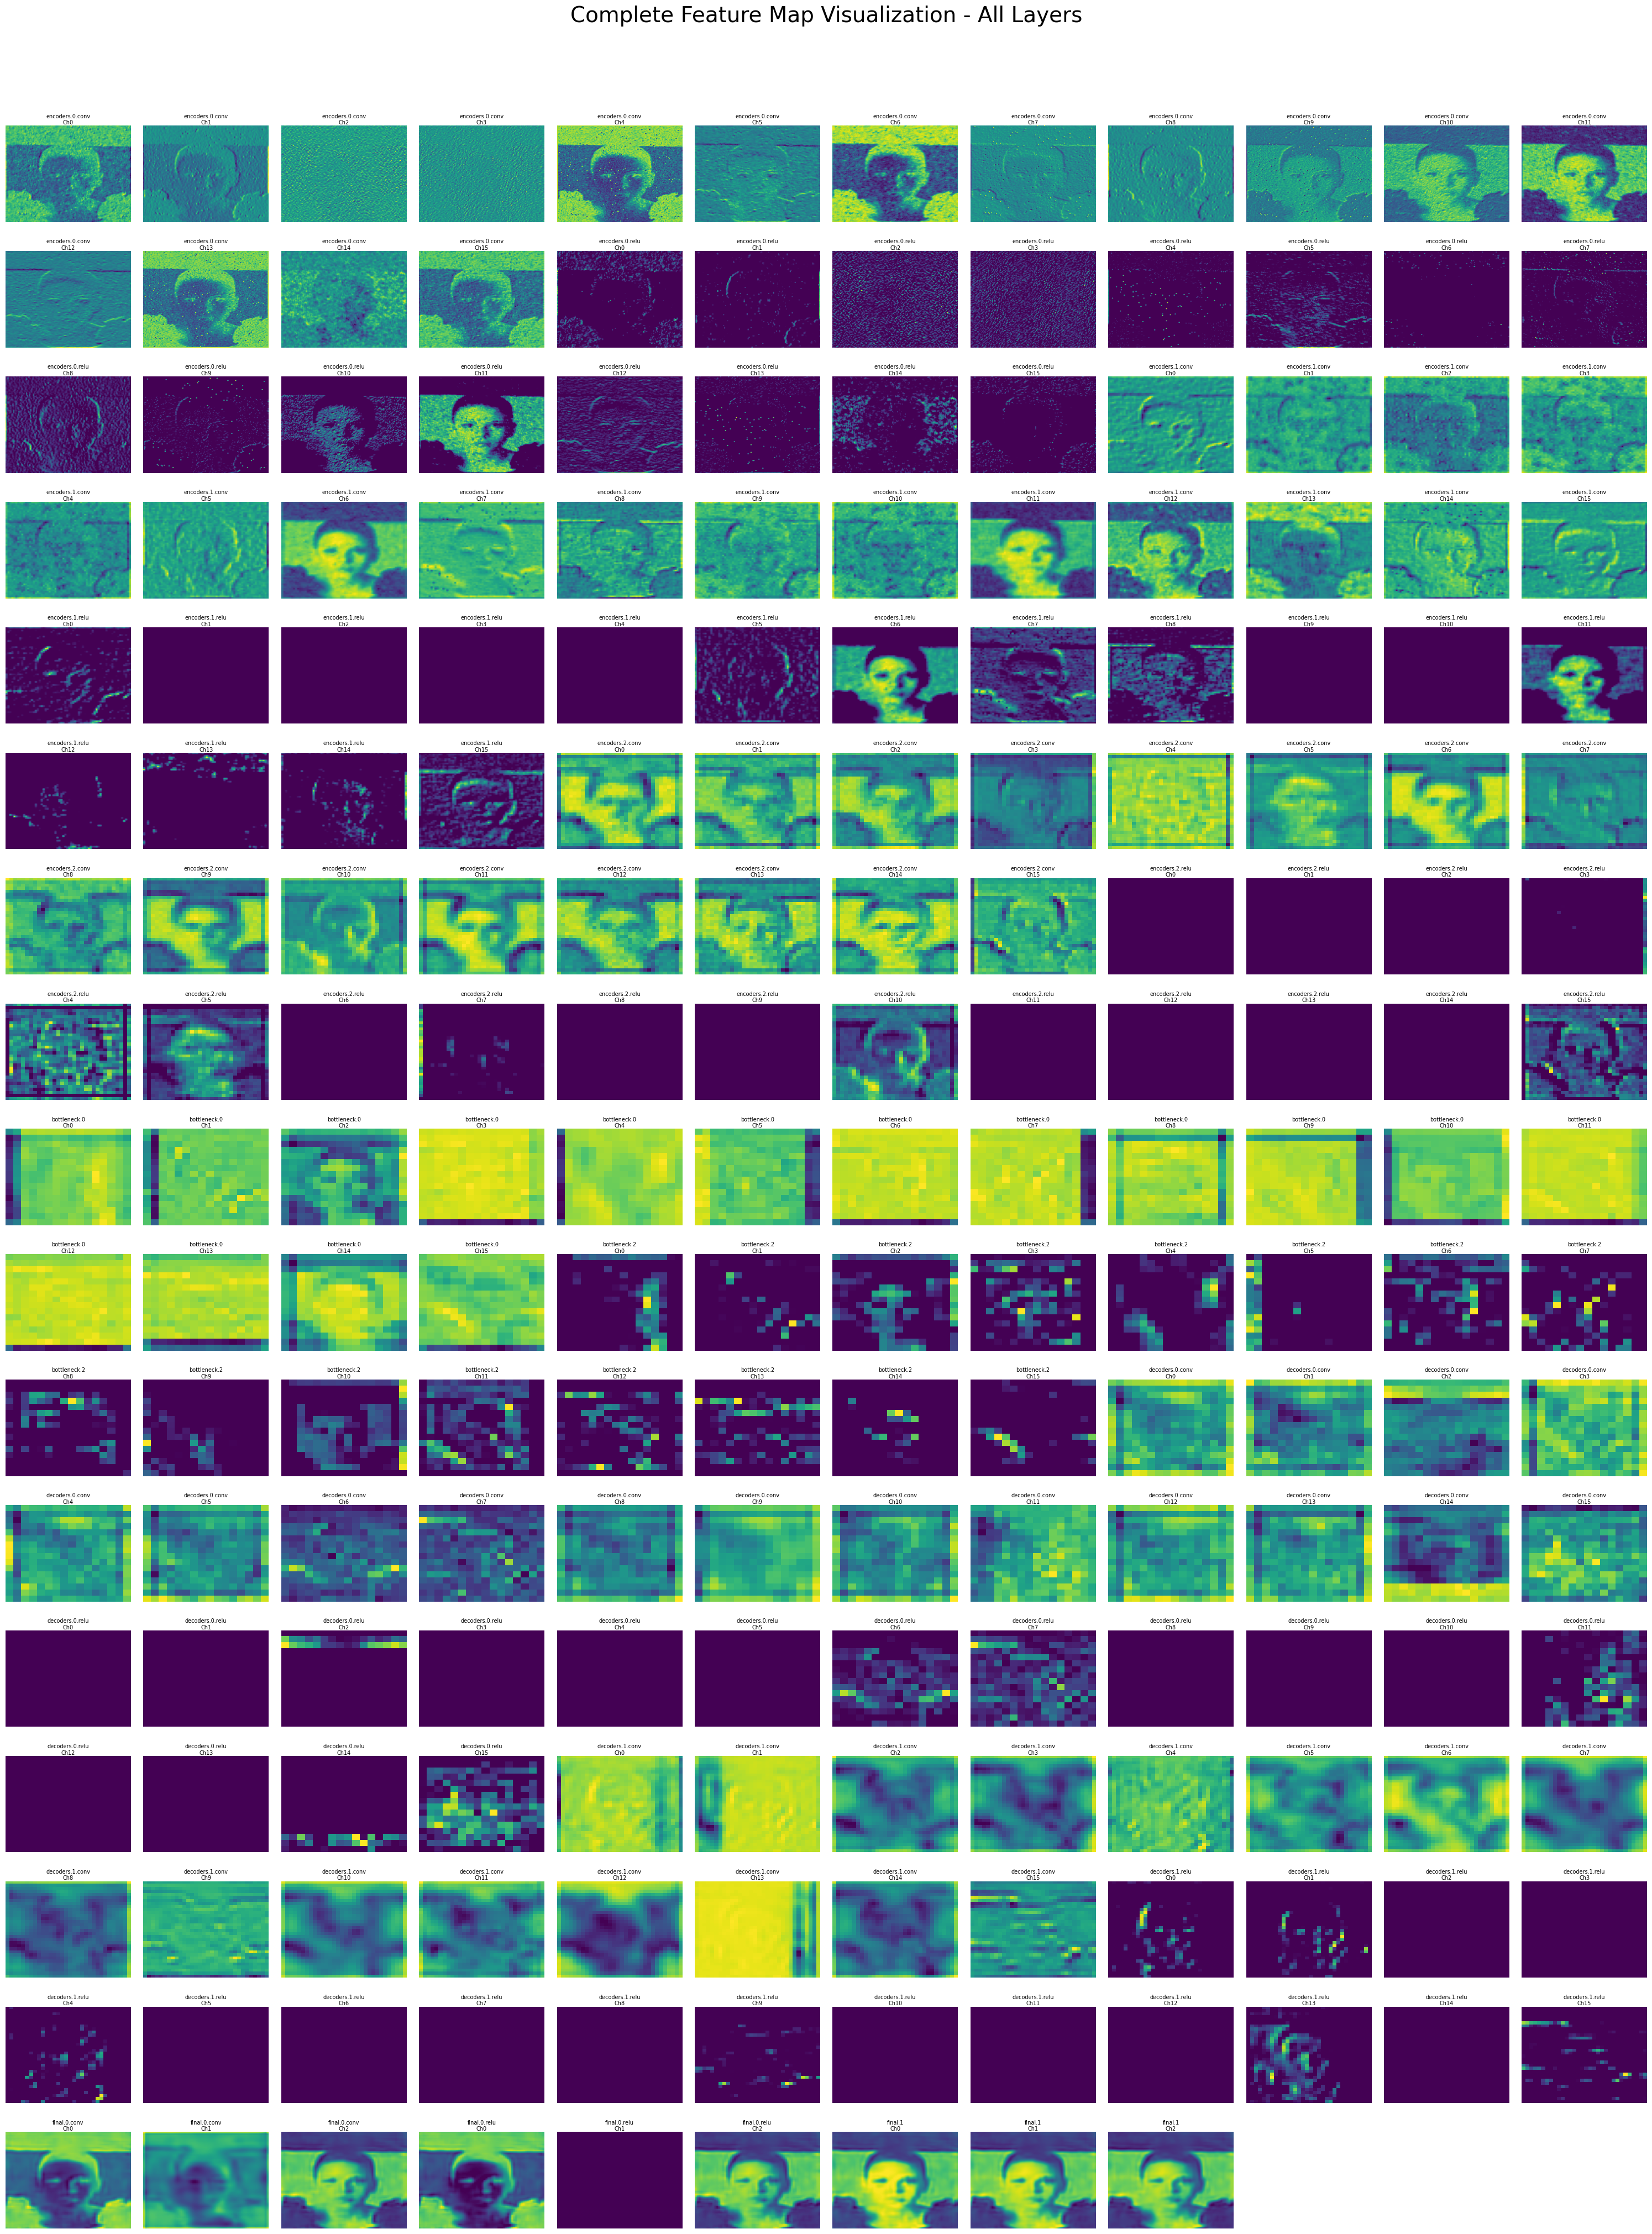


VISUALIZATION COMPLETE
Layers processed: 15
Feature maps displayed: 201
Grid size: 17 x 12
Saved as: autoencoder_features_all_layers_12col.png


Autoencoder(
  (encoders): ModuleList(
    (0): DownSamplingBlock(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): DownSamplingBlock(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): DownSamplingBlock(
      (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (bottleneck): Sequential(
    (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (decoders): ModuleList(
    (0): UpSamplingBlock(
    

In [24]:
### START CODE HERE ###

sample_input, _ = next(iter(testloader))
sample_input = sample_input[:1]  # Take only first image

print("Input shape:", sample_input.shape)
print("="*60)

# Visualize ALL feature maps in 12-column layout
visualize_feature_map(sample_input, "autoencoder_features")

model = Autoencoder(channels=[64,128,256])
checkpoint = torch.load(
    "./random_autoencoder_checkpoint_epoch_83.pth",
    map_location="cpu"
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

### END CODE HERE ###

---

# Questions

1. How many combinations of hyperparameter values (trials) were evaluated during the hyperparameter tuning process?
2. What are the top 3 best parameters and their corresponding tuning results for the model?
3. Analyze and compare the similarities and differences between the top 3 parameters in terms of model architecture, loss, performance, etc.




# 1

## Grid Search Configuration
```python
config = {
    "architecture": tune.grid_search(
        [[32, 64, 128], [64, 128, 256], [64, 128, 256, 512]]  # → 3 options
    ),
    "lr": tune.grid_search([0.01, 0.0001]),                   # → 2 options
    "batch_size": tune.grid_search([2, 16]),                  # → 2 options
    "num_epochs": tune.grid_search([100, 300]),               # → 2 options
    "optimizer": tune.grid_search(["Adam", "RMSProp"]),       # → 2 options
}
```

**Total combinations:** 3 × 2 × 2 × 2 × 2 = **48 trials**

## Random Search Configuration
```python
config = {
    "architecture": tune.choice(
        [[32, 64, 128], [64, 128, 256], [64, 128, 256, 512]]  # → 3 options
    ),
    "lr": tune.choice([0.01, 0.0001]),                        # → 2 options
    "batch_size": tune.choice([2, 16]),                       # → 2 options
    "num_epochs": tune.randint(100, 300),                     # → 200 options
    "optimizer": tune.choice(["Adam", "RMSProp"]),            # → 2 options
}
```

**Theoretical combinations:** 3 × 2 × 2 × 200 × 2 = **4,800 possibilities**  
**Actual samples:** Capped at **80 trials**

# 2

## Grid Search Results - Top 3 Performers

| Rank | Architecture | Learning Rate | Batch Size | Epochs | Optimizer | Train Loss | Val Loss | Val PSNR | Val SSIM |
|------|-------------|---------------|------------|---------|-----------|----------|----------|----------|----------|
| 1    | [64, 128, 256] | 0.0008 | 16 | 100 | Adam | 0.005017876121 |0.004809503958|	23.67410113|	0.7124888301|
| 2    | [64, 128, 256] | 0.0001 | 16 | 100 | Adam |0.005335150218|	0.005556768493	|22.99257338	|0.6937189102|
| 3    | [64, 128, 256] | 0.001  | 16 | 100 | Adam | 0.005559738468	|0.005562507842|	23.01864442|	0.7059691548|


## Random Search Results - Top 3 Performers

| Rank | Architecture | Learning Rate | Optimizer | Train Loss | Val Loss | Val PSNR | Val SSIM |
|------|-------------|---------------|-----------|------------|----------|----------|----------|
| 1    | [64, 128, 256] | 0.000278 | Adam | 0.003510 | 0.003431 | 25.224 | 0.771 |
| 2    | [64, 128, 256] | 0.000205 | Adam | 0.003710 | 0.003730 | 24.830 | 0.755 |
| 3    | [64, 128, 256, 512] | 0.000237 | Adam | 0.003881 | 0.004453 | 23.989 | 0.710 |


# 3

### Key Observations for Grid
- **Optimal architecture:** [64, 128, 256] consistently performs best
- **Learning rate sweet spot:** Around 0.0001-0.001 range
- **Batch size:** 16 is optimal for this configuration
- **Training efficiency:** 100 epochs sufficient
- **Optimizer preference:** Adam outperforms RMSProp for this setup

### Key Observations for Random
- **Architecture preference:** [64, 128, 256] dominates top results, with [64, 128, 256, 512] showing potential
- **Fine-tuned learning rates:** Random search discovered optimal rates around 0.0002-0.0003
- **Consistent optimizer:** Adam again proves superior
- **Random search advantage:** Found more precise learning rate values than grid search discrete options